In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_samples = 5000

data = {
    'Customer_ID': np.arange(1001, 1001 + n_samples),
    'Age': np.random.randint(22, 65, n_samples),
    'Income_Monthly': np.random.randint(2000, 15000, n_samples),
    'Credit_Score': np.random.randint(300, 850, n_samples),
    'Debt_to_Income_Ratio': np.round(np.random.uniform(0.1, 0.6, n_samples), 2),
    'Experience_Years': np.random.randint(0, 40, n_samples),
    'Existing_Loans_Count': np.random.randint(0, 5, n_samples),
    'Savings_Balance': np.random.randint(100, 150000, n_samples),
    'Missed_Payments_Last_Year': np.random.choice([0, 1, 2, 3], n_samples, p=[0.7, 0.15, 0.1, 0.05])
}

df = pd.DataFrame(data)

# Logic for Target Variable (Default_Status)
# Hum ek hidden score banate hain jiski bunyaad par log default karenge
# (Asli life mein ye factors default ka sabab bante hain)
risk_score = (
    (df['Credit_Score'] < 500) * 0.4 + 
    (df['Debt_to_Income_Ratio'] > 0.45) * 0.3 + 
    (df['Missed_Payments_Last_Year'] >= 1) * 0.3 +
    (df['Savings_Balance'] < 1000) * 0.2 -
    (df['Experience_Years'] > 10) * 0.1
)

# Agar risk score 0.4 se upar hai to Default (1), warna Loyal (0)
df['Default_Status'] = (risk_score + np.random.normal(0, 0.1, n_samples) > 0.4).astype(int)

# "High-Value Bypass" Logic: Jinka balance 100k+ hai unka risk kam kar dete hain
df.loc[df['Savings_Balance'] > 100000, 'Default_Status'] = np.random.choice([0, 1], size=len(df[df['Savings_Balance'] > 100000]), p=[0.95, 0.05])

# Save or View
print(df.head())
print("\nClass Distribution:\n", df['Default_Status'].value_counts())

   Customer_ID  Age  Income_Monthly  Credit_Score  Debt_to_Income_Ratio  \
0         1001   60           14948           438                  0.23   
1         1002   50            6059           575                  0.18   
2         1003   36            4773           590                  0.45   
3         1004   64           11878           352                  0.23   
4         1005   29           10383           409                  0.56   

   Experience_Years  Existing_Loans_Count  Savings_Balance  \
0                34                     3           121796   
1                18                     4             1894   
2                20                     4           126242   
3                32                     2            10821   
4                22                     1             5786   

   Missed_Payments_Last_Year  Default_Status  
0                          0               0  
1                          0               0  
2                          0       

,Customer_ID,Age,Income_Monthly,Credit_Score,Debt_to_Income_Ratio,Experience_Years,Existing_Loans_Count,Savings_Balance,Missed_Payments_Last_Year,Default_Status
0,1001,60,14948,438,0.23,34,3,121796,0,0
1,1002,50,6059,575,0.18,18,4,1894,0,0
2,1003,36,4773,590,0.45,20,4,126242,0,0
3,1004,64,11878,352,0.23,32,2,10821,0,0
4,1005,29,10383,409,0.56,22,1,5786,0,1
...,...,...,...,...,...,...,...,...,...,...
4995,5996,64,6323,664,0.58,35,3,38894,0,0
4996,5997,44,7773,449,0.59,1,3,20853,0,1
4997,5998,25,14786,570,0.43,21,1,113784,0,0
4998,5999,48,4568,415,0.36,21,3,27338,2,1


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

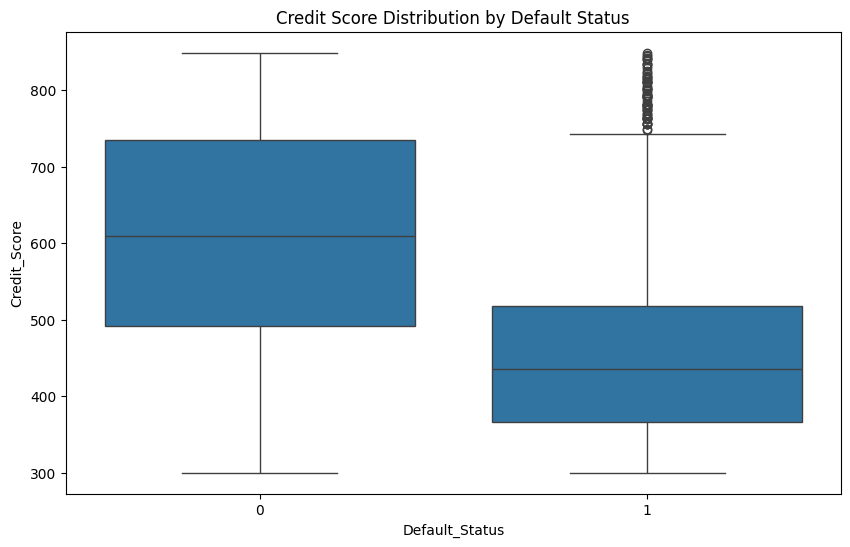

In [4]:
plt.figure(figsize=(10, 6))
# 'Default_Status' 0: Paid, 1: Defaulted
sns.boxplot(x='Default_Status', y='Credit_Score', data=df)
plt.title('Credit Score Distribution by Default Status')
plt.show()

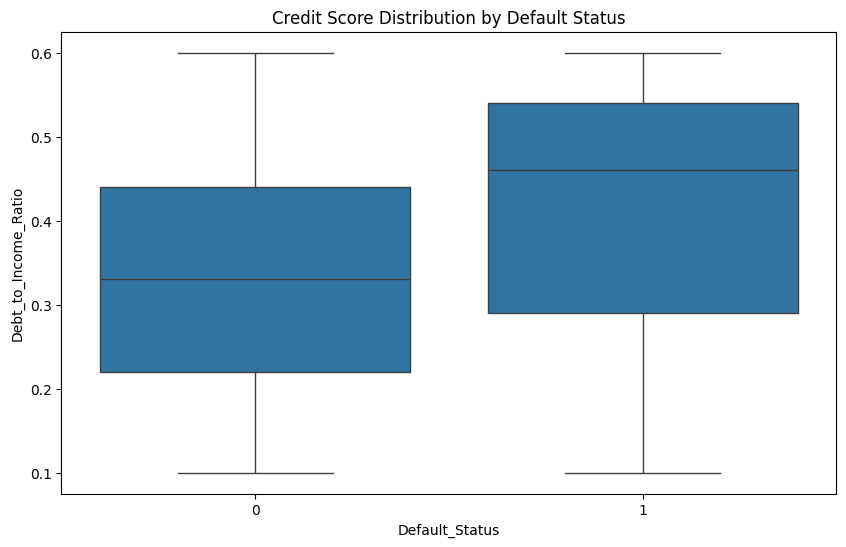

In [5]:
plt.figure(figsize=(10, 6))
# 'Default_Status' 0: Paid, 1: Defaulted
sns.boxplot(x='Default_Status', y='Debt_to_Income_Ratio', data=df)
plt.title('Credit Score Distribution by Default Status')
plt.show()

In [6]:
df['Debt_Stress_Index'] = df['Credit_Score'] * df['Debt_to_Income_Ratio']

In [7]:
df.head(7)

,Customer_ID,Age,Income_Monthly,Credit_Score,Debt_to_Income_Ratio,Experience_Years,Existing_Loans_Count,Savings_Balance,Missed_Payments_Last_Year,Default_Status,Debt_Stress_Index
0,1001,60,14948,438,0.23,34,3,121796,0,0,100.74
1,1002,50,6059,575,0.18,18,4,1894,0,0,103.50
2,1003,36,4773,590,0.45,20,4,126242,0,0,265.50
3,1004,64,11878,352,0.23,32,2,10821,0,0,80.96
4,1005,29,10383,409,0.56,22,1,5786,0,1,229.04
5,1006,42,12178,303,0.16,5,0,95103,0,1,48.48
6,1007,60,13815,346,0.26,31,2,62822,0,0,89.96


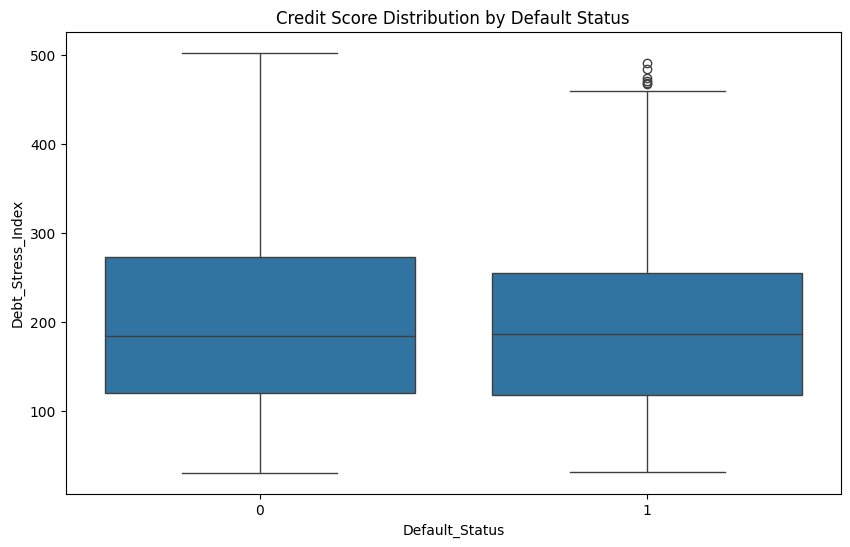

In [8]:
plt.figure(figsize=(10, 6))
# 'Default_Status' 0: Paid, 1: Defaulted
sns.boxplot(x='Default_Status', y='Debt_Stress_Index', data=df)
plt.title('Credit Score Distribution by Default Status')
plt.show()

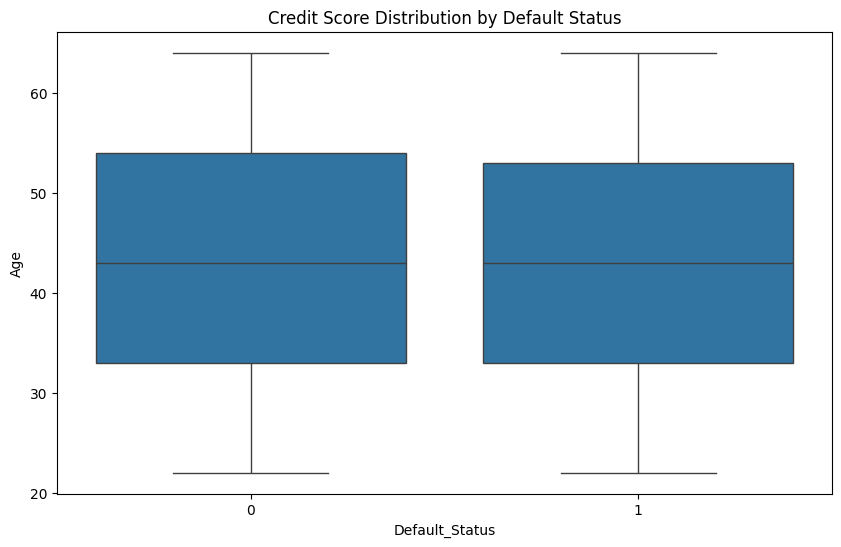

In [9]:
plt.figure(figsize=(10, 6))
# 'Default_Status' 0: Paid, 1: Defaulted
sns.boxplot(x='Default_Status', y='Age', data=df)
plt.title('Credit Score Distribution by Default Status')
plt.show()

In [10]:
df['Monthly_Debt_Amount'] = df['Income_Monthly'] * df['Debt_to_Income_Ratio']

In [38]:
df.drop('Customer_ID',axis=1,inplace=True)

In [39]:
df.to_csv('testing.csv')

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Default_Status',axis=1),df['Default_Status'],test_size=0.2,random_state=42)

In [12]:
X_train.drop('Customer_ID',axis=1,inplace=True)

In [13]:
X_test.drop('Customer_ID',axis=1,inplace=True)

In [14]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(max_depth=8)

In [15]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [16]:
y_pred=model.predict(X_test)

In [17]:
from sklearn.metrics import classification_report,confusion_matrix

In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       790
           1       0.94      0.77      0.84       210

    accuracy                           0.94      1000
   macro avg       0.94      0.88      0.90      1000
weighted avg       0.94      0.94      0.94      1000



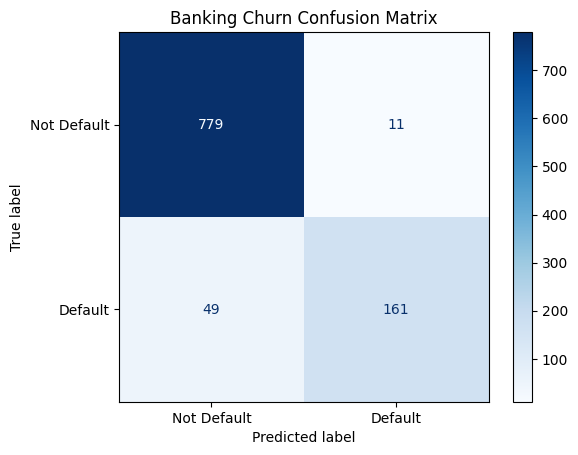

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix generate karein
cm = confusion_matrix(y_test, y_pred)

# Display karein
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Banking Churn Confusion Matrix')
plt.show()

In [20]:
y_prob=model.predict_proba(X_test)[:,-1]

In [21]:
y_pred=(y_prob>0.43).astype(int)

In [22]:
y_pred.shape

(1000,)

In [23]:
y_test.shape

(1000,)

In [24]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       790
           1       0.88      0.81      0.84       210

    accuracy                           0.94      1000
   macro avg       0.91      0.89      0.90      1000
weighted avg       0.93      0.94      0.94      1000



In [25]:
confusion_matrix(y_test,y_pred)

array([[766,  24],
       [ 40, 170]])

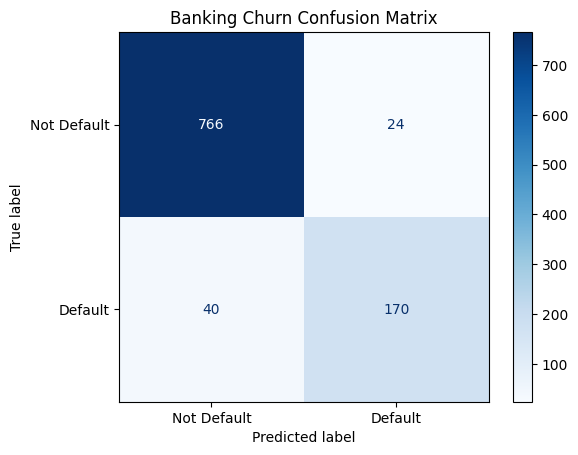

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix generate karein
cm = confusion_matrix(y_test, y_pred)

# Display karein
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Banking Churn Confusion Matrix')
plt.show()

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(
    n_estimators=300,        # Zyada trees taake model complex patterns seekh sake
    learning_rate=0.05,      # Choti steps taake model "over-shoot" na kare
    max_depth=4,             # Depth kam rakhi hai taake model 'Ratta' (Overfit) na mare
    min_samples_split=10,    # Har branch tabhi bane jab kam az kam 10 log hon
    min_samples_leaf=5,      # Har leaf par 5 customers hona zaroori hain
    subsample=0.8,           # Har tree 80% data dekhega (Randomness for stability)
    random_state=42
)

In [28]:
model.fit(X_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

In [29]:
y_pred=model.predict(X_test)

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       790
           1       0.89      0.81      0.85       210

    accuracy                           0.94      1000
   macro avg       0.92      0.89      0.90      1000
weighted avg       0.94      0.94      0.94      1000



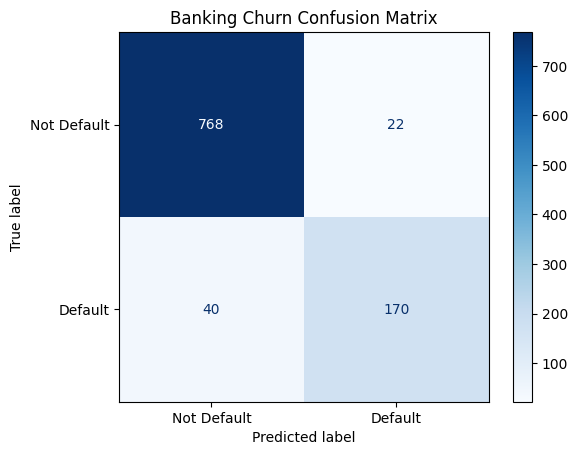

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix generate karein
cm = confusion_matrix(y_test, y_pred)

# Display karein
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Banking Churn Confusion Matrix')
plt.show()

In [37]:
import shap

# Model ko explainer mein daalein
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[8,:], X_test.iloc[8,:])

In [ ]:
import joblib

# Model ko 'banking_model.pkl' ke naam se save karein
joblib.dump(model, 'banking_model.pkl')

print("Model baghair feature selector ke save ho gaya hai!")

In [ ]:
import joblib

# Model load karein
loaded_model = joblib.load('banking_model.pkl')

In [ ]:
predictions = loaded_model.predict(X_test)

print("Model successfully load ho gaya aur predictions tayyar hain!")

In [ ]:
new_customer = pd.DataFrame({
    'Age': [35],
    'Income_Monthly': [8000],
    'Credit_Score': [450],
    'Debt_to_Income_Ratio': [0.6],
    'Experience_Years': [5],
    'Existing_Loans_Count': [2],
    'Savings_Balance': [1200],
    'Missed_Payments_Last_Year': [1],
    'Debt_Stress_Index': [270],         # (450 * 0.6)
    'Monthly_Debt_Amount': [4800]       # (8000 * 0.6)
})

In [ ]:
predictions = loaded_model.predict(new_customer)

In [ ]:
predictions